# Partie 1 — Chargement et exploration

## Les imports

In [38]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import string
import pickle
import joblib
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import TextVectorization

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

**Chargement du modèle spacy**

In [39]:
# commande à faire python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
print("Modèle spaCy chargé.")

Modèle spaCy chargé.


## 1.1 Chargement et constitution du corpus de titres


**Écrivez une fonction load_titles(filepath: str) -> pd.DataFrame qui :**

* Charge le fichier CSV
* Sélectionne et renomme les colonnes utiles : title → text, label → label
* Convertit les labels textuels en entiers : REAL → 1, FAKE → 0
* Supprime les lignes dont le titre est vide ou nul
* Affiche un résumé : nombre de titres par classe, proportion, longueur moyenne
* Sauvegardez le DataFrame résultant dans data/titles_clean.csv.

In [40]:
df_raw = pd.read_csv("../data/news.csv")
print(f"nb_lignes de news.csv brut : {df_raw.shape[0]}")
print(f"nb_colonnes de news.csv brut : {df_raw.shape[1]}")
print(df_raw.info())
print(df_raw.isnull().sum())
print(df_raw.head(10))

nb_lignes de news.csv brut : 6335
nb_colonnes de news.csv brut : 4
<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  6335 non-null   int64
 1   title       6335 non-null   str  
 2   text        6335 non-null   str  
 3   label       6335 non-null   str  
dtypes: int64(1), str(3)
memory usage: 198.1 KB
None
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64
   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   
5        6903                                        Tehran, USA  

In [41]:
def load_titles(filepath: str) -> pd.DataFrame:
    """
    - Charge le dataset de news
    - nettoie succintement (suppression des textes vides)
    - renomme la colonne "title" en "text"
    - transforme la colonne label en colonne numérique ("REAL": 1, "FAKE": 0)
    - crée une colonne length_tokens qui represente le nombre de tokens dans la news
    ensuite l'enregistre dans /data

    Parameters
    ----------
    filepath : str
        Chemin vers le fichier CSV source.

    Returns
    -------
    pd.DataFrame
        DataFrame contenant :
        - text : titre de l'article
        - label : 1 pour REAL, 0 pour FAKE
    """
    # Chargement du fichier
    df = pd.read_csv(filepath)

    # Copie des 2 colonnes utiles "title" et "label"
    df = df[["title", "label"]].copy()

    # Renommage de la colonne "title" en "text", la colonne label porte déjà le bon nom
    df = df.rename(columns={"title": "text"}) #,"label" : "label" pas nécessaire

    # Suppression des titres vides
    df["text"] = df["text"].fillna("")
    df["text"] = df["text"].str.strip()
    df = df[df["text"]!= ""].copy()

    # Transformation de la colonne label en colonne numérique "REAL": 1, "FAKE": 0 
    df["label"] = df["label"].map({"REAL": 1, "FAKE": 0}) #.astype(int)
    # df = df[df["label"].isin([0, 1])].copy()

    # Création de la colonne "length_tokens" qui donne le nombre de mots du titre
    df["nb_tokens"] = df["text"].apply(lambda x: len(str(x).split()))

    print("RESUME :")
    print("-"*10)

   
    vc = df["label"].value_counts()
    nb_real = vc.iloc[0]
    nb_fake = vc.iloc[1]
    print(f"Nombre de news REAL : {nb_real}")
    print(f"Nombre de news FAKE : {nb_fake}")

    print()
  
    vcn = df["label"].value_counts(normalize=True)
    pct_real = round(vcn.iloc[0],4)*100
    pct_fake = round(vcn.iloc[1],4)*100

    print(f"Pourcentage de news REAL : {pct_real}%")
    print(f"Pourcentage de news FAKE : {pct_fake}%")

    print()
    print(f"Nombre moyen de mots par titre de news : {int(df['nb_tokens'].mean())} mots")

    df.to_csv("../data/titles_clean.csv", index=False)

    return df

In [42]:
df_clean = load_titles("../data/news.csv") 
print(df_clean.info())
print(df_clean.head(5))

RESUME :
----------
Nombre de news REAL : 3171
Nombre de news FAKE : 3164

Pourcentage de news REAL : 50.06%
Pourcentage de news FAKE : 49.94%

Nombre moyen de mots par titre de news : 10 mots
<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       6335 non-null   str  
 1   label      6335 non-null   int64
 2   nb_tokens  6335 non-null   int64
dtypes: int64(2), str(1)
memory usage: 148.6 KB
None
                                                text  label  nb_tokens
0                       You Can Smell Hillary’s Fear      0          5
1  Watch The Exact Moment Paul Ryan Committed Pol...      0         14
2        Kerry to go to Paris in gesture of sympathy      1          9
3  Bernie supporters on Twitter erupt in anger ag...      0         15
4   The Battle of New York: Why This Primary Matters      1          9


# 1.2 Analyse exploratoire




* Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

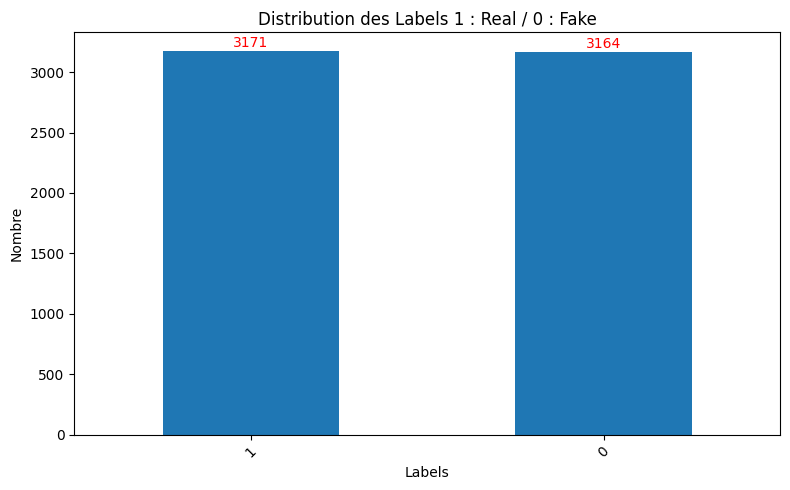

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
counts = df_clean['label'].value_counts()
ax = counts.plot(kind='bar')

ax.set_xlabel("Labels")
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Nombre")
ax.set_title("Distribution des Labels 1 : Real / 0 : Fake")
ax.bar_label(ax.containers[0], padding=1, color="red")

plt.tight_layout()
plt.show()


**=> On peut considérer que le corpus est équilibré avec 50.06% de REAL et 49.94% de FAKE**  

* Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

REAL
----------
Le nombre minimum de mots par titre : 2
Le nombre maximum de mots par titre : 27
La médiane de mots par titre : 10
FAKE
----------
Le nombre minimum des mots par titre : 1
Le nombre maximum des mots par titre : 53
La médiane des mots par titre : 11


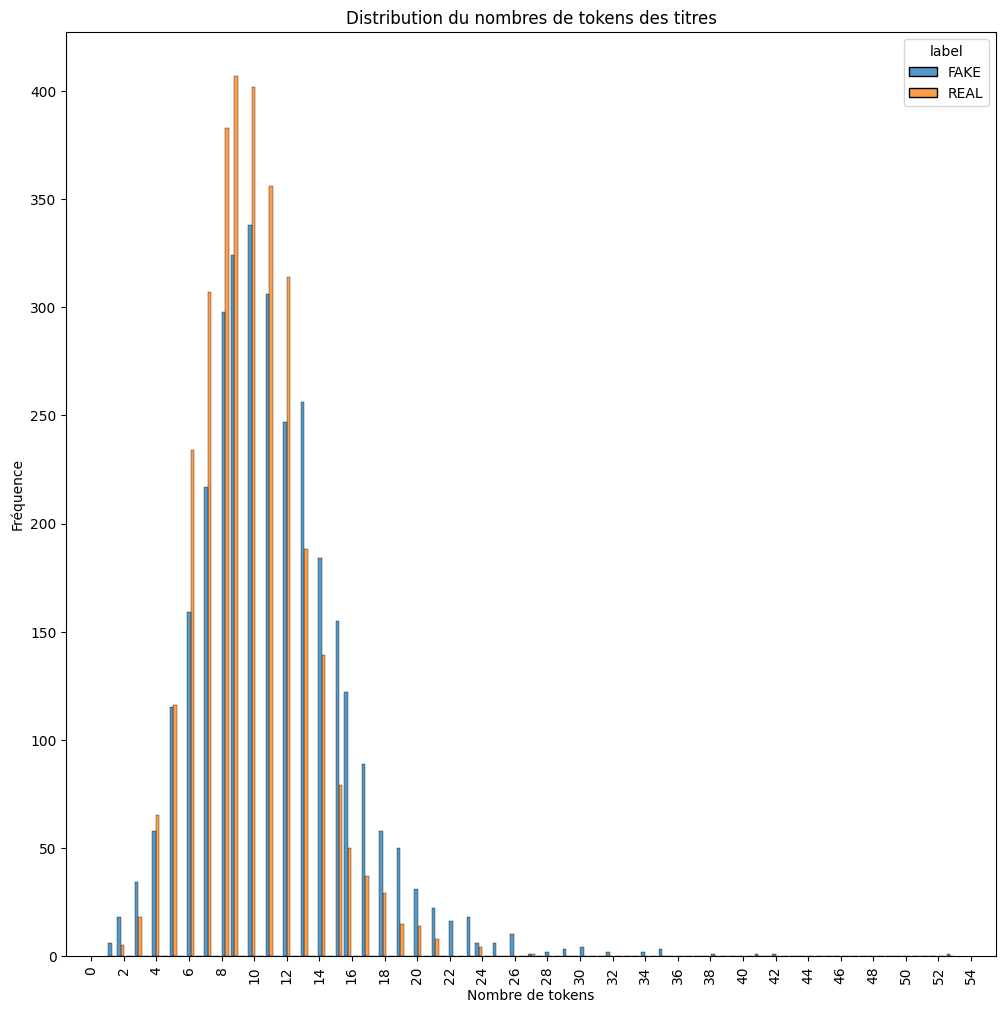

In [44]:
real_nb_tokens = df_clean[df_clean["label"] == 1]["nb_tokens"]
fake_nb_tokens = df_clean[df_clean["label"] == 0]["nb_tokens"]

# Affichage pour les titres REAL
print("REAL")
print("-"*10)
print(f"Le nombre minimum de mots par titre : {real_nb_tokens.min()}")
print(f"Le nombre maximum de mots par titre : {real_nb_tokens.max()}")
print(f"La médiane de mots par titre : {int(real_nb_tokens.median())}")

print("=" * 30) # Ligne de séparation

# Affichage pour les titres FAKE
print("FAKE")
print("-"*10)
print(f"Le nombre minimum des mots par titre : {fake_nb_tokens.min()}")
print(f"Le nombre maximum des mots par titre : {fake_nb_tokens.max()}")
print(f"La médiane des mots par titre : {int(fake_nb_tokens.median())}")

# plt.figure(figsize=(10, 5))
# plt.hist(fake_nb_tokens, bins=30, alpha=0.7, label="FAKE")
# plt.hist(real_nb_tokens, bins=30, alpha=0.7, label="REAL")
# plt.xticks(np.arange(0, 56, 2), rotation=45)
# plt.title("Distribution du nombres de tokens des titres")
# plt.xlabel("Nombre de tokens")
# plt.ylabel("Fréquence")
# plt.legend()
# plt.show()

import seaborn as sns
legend_map = {1: "REAL", 0: "FAKE"}
plt.figure(figsize=(12, 12))
sns.histplot(data=df_clean, x='nb_tokens', hue=df_clean['label'].map(legend_map), multiple="dodge", shrink=0.8)
# On garde tes graduations précises
plt.xticks(np.arange(0, 56, 2), rotation=90)
plt.title("Distribution du nombres de tokens des titres")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")

plt.show()



**=> On observe qu'au delà de 27 tokens dans le titres, il y a une forte probabilité d'être sur une FAKE news. Par contre, on**
**observe également que les titres FAKE et REAL sont concentrés entre 4 et 16 tokens en majorité. La longueur ne suffit pas**
**pour déterminer si on a affaire à un titre FAKE ou REAL**

* Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

Les 20 tokens les plus fréquents (REAL) :
[('to', 724), ('the', 635), ('in', 500), ('Trump', 432), ('of', 392), ('for', 332), ('The', 319), ('a', 299), ('on', 293), ('Clinton', 285), ('and', 282), ('is', 254), ('GOP', 213), ('Obama', 193), ('Donald', 185), ('Hillary', 168), ('Why', 136), ('How', 118), ('2016', 114), ('House', 109)]
Les 20 tokens les plus fréquents (FAKE) :
[('The', 580), ('to', 559), ('the', 532), ('of', 472), ('in', 353), ('Trump', 348), ('To', 314), ('Hillary', 304), ('on', 296), ('and', 279), ('for', 262), ('Clinton', 250), ('a', 194), ('Is', 186), ('In', 185), ('by', 172), ('–', 171), ('-', 161), ('A', 159), ('Of', 152)]


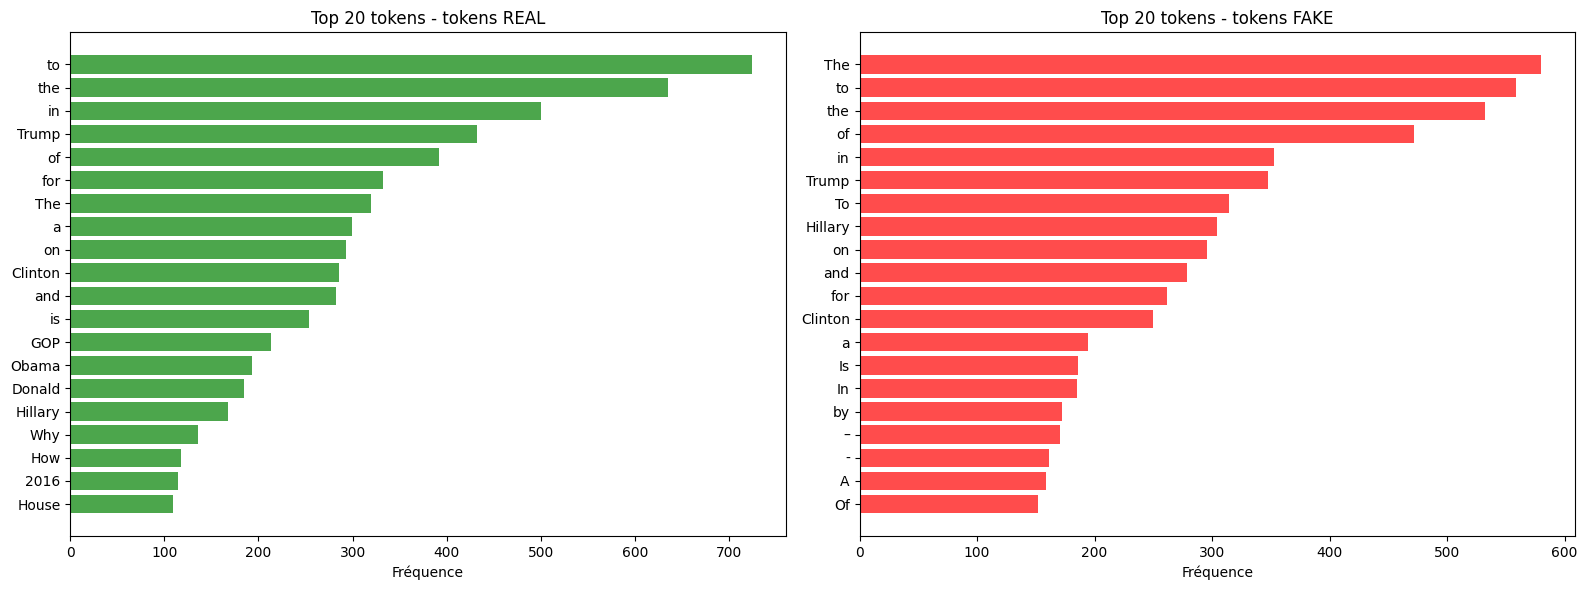

In [45]:
from collections import Counter

def get_list_tokens(df) :
    list_tokens = []
    for list_words in df["tokens"] :
        for word in list_words :
            list_tokens.append(word)
    return list_tokens

df_clean["tokens"] = df_clean["text"].str.split()
df_real = df_clean[df_clean["label"]==1].copy()
df_fake = df_clean[df_clean["label"]==0].copy()

list_tokens_real = get_list_tokens(df_real)
list_tokens_fake = get_list_tokens(df_fake)

list_occ_tokens_real = Counter(list_tokens_real)
list_occ_tokens_fake = Counter(list_tokens_fake)


print("Les 20 tokens les plus fréquents (REAL) :")
print(list_occ_tokens_real.most_common(20))
print("Les 20 tokens les plus fréquents (FAKE) :")
print(list_occ_tokens_fake.most_common(20))


# # Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 20 tokens real
words_pos, counts_pos = zip(*list_occ_tokens_real.most_common(20))
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 20 tokens - tokens REAL')
axes[0].invert_yaxis()

# 20 tokens fake
words_neg, counts_neg = zip(*list_occ_tokens_fake.most_common(20))
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 20 tokens - tokens FAKE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**=> on remarque que la majorité des mots les plus fréquents sont des mots qui n'apportent aucune information sur la nature du titre.** 

* Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

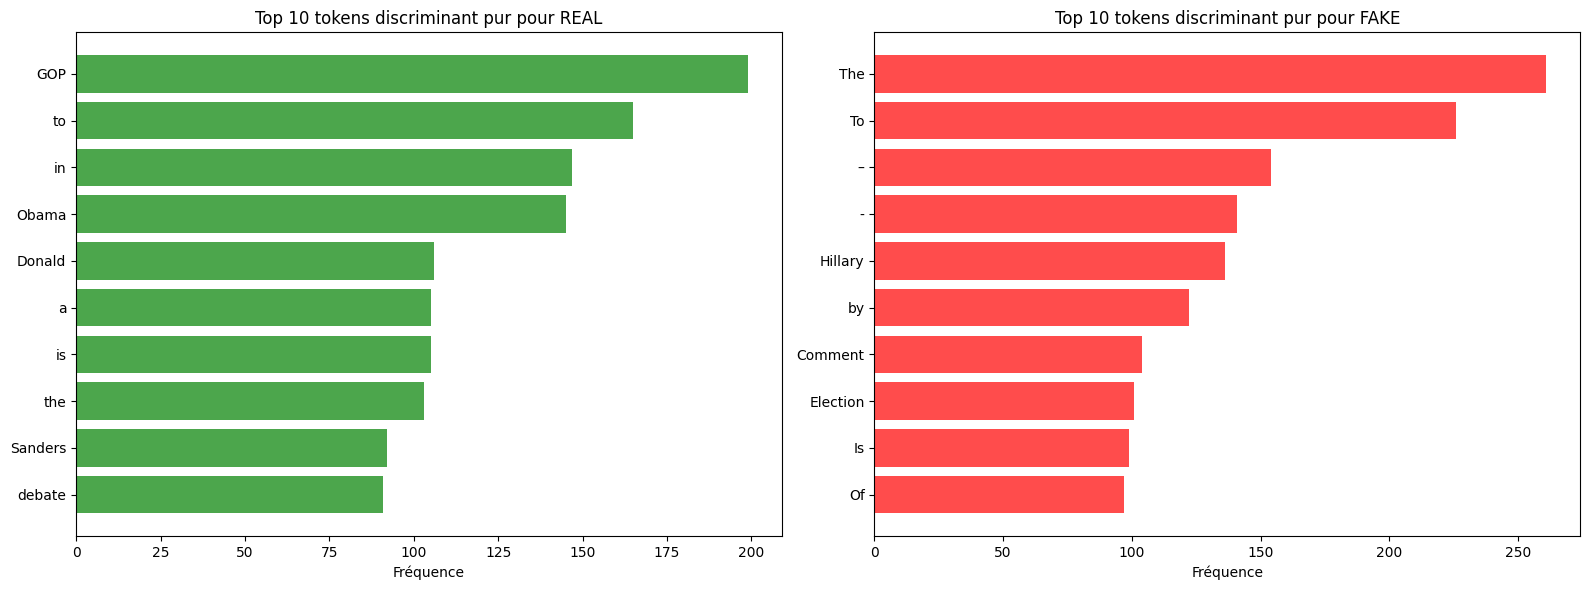

In [46]:
list_discr_pur_real = list_occ_tokens_real - list_occ_tokens_fake
list_discr_pur_fake = list_occ_tokens_fake - list_occ_tokens_real

# # Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 20 tokens real
words_pos, counts_pos = zip(*list_discr_pur_real.most_common(10))
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 10 tokens discriminant pur pour REAL')
axes[0].invert_yaxis()

# 20 tokens fake
words_neg, counts_neg = zip(*list_discr_pur_fake.most_common(10))
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 10 tokens discriminant pur pour FAKE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**=> On observe que malgré la volonté de ne garder que les discriminat pur pour chaque label, la casse des caractères laisse passer des tokens**
**identiques comme par exemple "The" et "the", "is" et Is" etc...** 

* Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème

- "Bernie Sanders Says He Will Not Be a Candidate in 2020" (FAKE) : Pas de mot émotionnel donc classement dans REAL probable
- "Donald Trump: 'I will be the greatest jobs president that God ever created'" (REAL) : Adjectif "greatest" associé à "God" classement dans FAKE probable
-  

# Partie 2 — Nettoyage et prétraitement
## 2.1 Pipeline de nettoyage


Implémentez une fonction clean_title(text: str) -> str qui applique les traitements suivants dans l'ordre :

Mise en minuscules
Suppression des URLs et des mentions de type @username
Suppression de la ponctuation et des chiffres isolés
Expansion des contractions anglaises (don't → do not, isn't → is not, etc.) — implémentez un dictionnaire d'au moins 20 contractions courantes
Suppression des stopwords anglais (NLTK) à l'exception des mots de négation (not, no, never, neither) — justifiez ce choix dans une cellule Markdown
Lemmatisation avec spaCy (modèle en_core_web_sm)
Suppression des tokens de longueur inférieure à 2 caractères après lemmatisation
Appliquez cette fonction à l'ensemble du corpus et stockez le résultat dans une colonne text_clean.


In [61]:
import re


contractions_dict = {
    "isn't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "can't've": "cannot have",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'm": "i am",
    "i've": "i have",
    "it's": "it is",
    "let's": "let us",
    "shouldn't": "should not",
    "won't": "will not",
    "i'd" : "i had"
}


def clean_title(text: str) -> str :
    """Nettoyer et préparer le texte pour la modélisation"""

    # Minuscules
    text = text.lower()

    # Suppression URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Suppression mentions
    text = re.sub(r'@\w+|#\w+', '', text)    

    # Suppression caractères spéciaux (garder espaces et \' pour traitement des contractions)
    text = re.sub(r'[^a-z0-9\s\']', '', text)
    
    # Suppression espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    temp_text = []
    split_text = text.split()
    for word in split_text :
        if word in contractions_dict :
            temp_text.append(contractions_dict[word])
        else :
            temp_text.append(word)
    
    text = " ".join(temp_text)

    # Supprimer les stopwords sauf "not", "no", "never", "neither"
    stop_words = set(stopwords.words('english'))
    words_filtered = []
    for word in text.split() :
        if word in ["not", "no", "never", "neither"] or word not in stop_words :
            words_filtered.append(word)
        
    # Lemmatisation avec Spacy
    doc = nlp(" ".join(words_filtered))
    lemmas = [token.lemma_ for token in doc]
    
    # Supprimer les tokens de moins de 2 caractères
    lemmas = [word for word in lemmas if len(word) >= 2]
    print(lemmas)
    text = " ".join(lemmas)

    return text

print(clean_title("I'd like to don't work because i bought a new z skateboard"))


['like', 'not', 'work', 'buy', 'new', 'skateboard']
like not work buy new skateboard


**=> On conserve "not", "no", "never", "neither" pour garder la négation pour ne pas changer le sens du texte ---**
**"Donald Trump Is Changing His Campaign Slogan to Prove He’s Not Racist" deviendrait**
**"Donald Trump Is Changing His Campaign Slogan to Prove He’s Racist**


In [48]:
df_clean["text_clean"] = df_clean["text"].apply(clean_title)
print(df_clean[["text","text_clean"]].head(1))

                           text           text_clean
0  You Can Smell Hillary’s Fear  smell hillarys fear


## 2.2 Mesure de l'impact du nettoyage


Calculez et affichez :


Question écrite : Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

* La taille du vocabulaire avant et après nettoyage

In [49]:
vocabulaire_avant_nettoyage = list_discr_pur_fake + list_discr_pur_real

def get_list_tokens_clean(df) :
    list_tokens = []
    for list_words in df["tokens_clean"] :
        for word in list_words :
            list_tokens.append(word)
    return list_tokens

df_clean["tokens_clean"] = df_clean["text_clean"].str.split()
df_real_clean = df_clean[df_clean["label"]==1].copy()
df_fake_clean = df_clean[df_clean["label"]==0].copy()

list_tokens_real_clean = get_list_tokens_clean(df_real_clean)
list_tokens_fake_clean = get_list_tokens_clean(df_fake_clean)

list_occ_tokens_real_clean = Counter(list_tokens_real_clean)
list_occ_tokens_fake_clean = Counter(list_tokens_fake_clean)

list_discr_pur_real_clean = list_occ_tokens_real_clean - list_occ_tokens_fake_clean
list_discr_pur_fake_clean = list_occ_tokens_fake_clean - list_occ_tokens_real_clean

vocabulaire_apres_nettoyage = list_discr_pur_real_clean + list_discr_pur_fake_clean

size_vocabulaire_avant_nettoyage = len(vocabulaire_avant_nettoyage)
size_vocabulaire_apres_nettoyage = len(vocabulaire_apres_nettoyage)

print(f"Taille du vocabulaire avant nettoyage : {size_vocabulaire_avant_nettoyage} tokens")
print(f"Taille du vocabulaire après nettoyage : {size_vocabulaire_apres_nettoyage} tokens")

print(f"Après nettoyage, le vocabulaire a baissé de {round((1-size_vocabulaire_apres_nettoyage / size_vocabulaire_avant_nettoyage) * 100,2)}%")



Taille du vocabulaire avant nettoyage : 17145 tokens
Taille du vocabulaire après nettoyage : 7909 tokens
Après nettoyage, le vocabulaire a baissé de 53.87%


* La réduction moyenne de la longueur des titres (en tokens)

In [50]:
df_clean["nb_tokens_clean"] = df_clean["tokens_clean"].str.len()

print(df_clean[["tokens","nb_tokens","tokens_clean","nb_tokens_clean"]].head(5))

avg_reduction_length = (df_clean["nb_tokens"] - df_clean["nb_tokens_clean"]).mean()
print()
print(f"=> la réduction moyenne de la longueur des titres est de : {round(avg_reduction_length)} tokens")


                                              tokens  nb_tokens  \
0                 [You, Can, Smell, Hillary’s, Fear]          5   
1  [Watch, The, Exact, Moment, Paul, Ryan, Commit...         14   
2  [Kerry, to, go, to, Paris, in, gesture, of, sy...          9   
3  [Bernie, supporters, on, Twitter, erupt, in, a...         15   
4  [The, Battle, of, New, York:, Why, This, Prima...          9   

                                        tokens_clean  nb_tokens_clean  
0                            [smell, hillarys, fear]                3  
1  [watch, exact, moment, paul, ryan, commit, pol...               11  
2              [kerry, go, paris, gesture, sympathy]                5  
3  [bernie, supporter, twitter, erupt, anger, dnc...               10  
4               [battle, new, york, primary, matter]                5  

=> la réduction moyenne de la longueur des titres est de : 3 tokens


* Le nombre de titres devenus vides après nettoyage : comment les gérez-vous ?

In [51]:
nb_titre_vide = df_clean[df_clean["nb_tokens_clean"]==0].count()
# print(nb_titre_vide)

print(df_clean[df_clean["nb_tokens_clean"]==0])

df_clean = df_clean[df_clean["nb_tokens_clean"]!=0].copy()

print(df_clean[df_clean["nb_tokens_clean"]==0])

                                    text  label  nb_tokens  \
3456                                   :      0          1   
6037  C праздником ребята и спасибо вам!      0          6   

                                         tokens text_clean tokens_clean  \
3456                                        [:]                      []   
6037  [C, праздником, ребята, и, спасибо, вам!]                      []   

      nb_tokens_clean  
3456                0  
6037                0  
Empty DataFrame
Columns: [text, label, nb_tokens, tokens, text_clean, tokens_clean, nb_tokens_clean]
Index: []


**=> On décidera de supprimer les titres ayant une liste de tokens vide pour éviter des traitement inutiles** 

# Partie 3 — Représentation vectorielle
## 3.1 Vectorisation TF-IDF


Transformez les titres nettoyés en vecteurs numériques avec TfidfVectorizer de scikit-learn.

Paramètres à utiliser :

TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)
Découpez le corpus en train (80 %) et test (20 %) avec stratification sur les labels et random_state=42
Entraînez le vectoriseur uniquement sur le train, transformez train et test séparément
Sauvegardez le vectoriseur avec joblib

In [52]:
# Split train/test
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df_clean['text_clean'],
    df_clean['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_clean['label']
)

print(f"Train set: {X_train_clean.shape[0]}")
print(f"Test set: {X_test_clean.shape[0]}")
print(f"Train class distribution: {y_train_clean.value_counts()}")
print(f"Test class distribution: {y_test_clean.value_counts()}")

# TF-IDF Vectorization
print("\n=== TF-IDF Vectorization ===")

tfidf_clean = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)


X_train_tfidf_clean = tfidf_clean.fit_transform(X_train_clean)
X_test_tfidf_clean = tfidf_clean.transform(X_test_clean)


print(f"TF-IDF shape: {X_train_tfidf_clean.shape}")
print(f"Nombre de features: {len(tfidf_clean.get_feature_names_out())}")

# Sauvegarde sur le disque
joblib.dump(tfidf_clean, "../models/vectorizer.pkl")

print(f" tfidfVectorizer sauvegardé")

Train set: 5066
Test set: 1267
Train class distribution: label
1    2537
0    2529
Name: count, dtype: int64
Test class distribution: label
1    634
0    633
Name: count, dtype: int64

=== TF-IDF Vectorization ===
TF-IDF shape: (5066, 3000)
Nombre de features: 3000
 tfidfVectorizer sauvegardé


## 3.2 Embedding avec TensorFlow

**En parallèle du TF-IDF, préparez une seconde représentation basée sur des embeddings appris :**

* Utilisez tf.keras.layers.TextVectorization pour construire un vocabulaire d'index à partir des titres bruts (non lemmatisés)
* Fixez max_tokens=5000 et output_sequence_length=30 (padding/truncation)
* Cette couche sera intégrée directement dans les modèles de la Partie 4
* Question écrite : Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que misleading et deceptive sont sémantiquement proches ? Justifiez.

In [53]:
# import unicodedata

# df_clean["text_raw_emb"] = (
#     df_clean["text"]
#     .fillna("")
#     .astype(str)
#     .str.strip()
#     .str.lower()
# )

# def normalize(text: str) :
#     return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

# df_clean["text_raw_emb"] = df_clean["text_raw_emb"].apply(normalize)
# df_clean = df_clean[df_clean["nb_tokens_clean"]!=0].copy()

# X_train_raw_emb, X_test_raw_emb, y_train_raw_emb, y_test_raw_emb = train_test_split(
#     df_clean["text_raw_emb"],
#     df_clean["label"],
#     test_size=0.2,
#     random_state=RANDOM_STATE,
#     stratify=df_clean["label"]
# )

# # text_vectorizer_raw = tf.keras.layers.TextVectorization(
# #     max_tokens=5000,
# #     output_sequence_length=30,
# #     standardize="lower_and_strip_punctuation" # Nettoyage standard intégré
# # )

# # vocabulaire_raw = [word for word, count in vocabulaire_avant_nettoyage.most_common(4998)]
# # text_vectorizer_raw.set_vocabulary(vocabulaire_raw)

# text_vectorizer_raw = tf.keras.layers.TextVectorization(
#     max_tokens=5000,
#     output_sequence_length=30,
#     standardize="lower_and_strip_punctuation" # Nettoyage standard intégré
# )

# # On "apprend" le vocabulaire sur les données propres (et seulement sur le train !)
# text_vectorizer_raw.adapt(X_train_raw_emb.to_numpy())

# # Vérification : si ce print marche, l'entraînement marchera aussi
# vocab = text_vectorizer_raw.get_vocabulary()
# print(f"Top 5 mots du vocabulaire : {vocab[:5]}")



# %% [markdown]
# ## 3.2 Embedding avec TensorFlow

# %%
"""
Question de l'énoncé :
Préparer une seconde représentation basée sur des embeddings appris à partir
des titres bruts non lemmatisés.
"""

import unicodedata

df_clean["text_raw_emb"] = (
    df_clean["text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

def normalize(text: str) -> str:
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")

df_clean["text_raw_emb"] = df_clean["text_raw_emb"].apply(normalize)

X_train_raw_emb, X_test_raw_emb, y_train_raw_emb, y_test_raw_emb = train_test_split(
    df_clean["text_raw_emb"],
    df_clean["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_clean["label"]
)

text_vectorizer_raw = tf.keras.layers.TextVectorization(
    max_tokens=5000,
    output_sequence_length=30,
    standardize="lower_and_strip_punctuation"
)

text_vectorizer_raw.adapt(X_train_raw_emb.to_numpy())

vocab = text_vectorizer_raw.get_vocabulary()
print(f"Taille du vocabulaire appris : {len(vocab)}")
print(f"Top 5 mots du vocabulaire : {vocab[:5]}")

Taille du vocabulaire appris : 5000
Top 5 mots du vocabulaire : ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('in')]


**=> Le TF-IDF traite chaque mot de manière isolé (sans lien avec les autres), alors que l'embedding**
**place mathématiquement les mots aux sens proches côte à côte.**
**Pour l'embedding misleading et deceptive sont synonymes car il apprend qu'ils sont utilisés dans les mêmes contextes**
**contrairement au TF-IDF qui ne voit que deux étiquettes différentes.**

# Partie 4 — Modélisation
## 4.1 Modèle baseline — réseau dense sur TF-IDF


Construisez un premier modèle avec l'API Sequential de TensorFlow, prenant en entrée les vecteurs TF-IDF :

Architecture minimale :

Dense(256, activation='relu')
Dropout(0.4)
Dense(128, activation='relu')
Dropout(0.3)
Dense(1, activation='sigmoid')
Compilez avec optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
Entraînez sur 30 epochs avec validation_split=0.15
Utilisez les callbacks suivants :
EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
ModelCheckpoint pour sauvegarder le meilleur modèle
Tracez les courbes de loss et d'accuracy (train vs validation)

Epoch 1/30
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5963 - loss: 0.6621
Epoch 1: val_accuracy improved from None to 0.79737, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6886 - loss: 0.5909 - val_accuracy: 0.7974 - val_loss: 0.4503
Epoch 2/30
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8440 - loss: 0.3581
Epoch 2: val_accuracy did not improve from 0.79737
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8683 - loss: 0.3111 - val_accuracy: 0.7908 - val_loss: 0.4917
Epoch 3/30
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9163 - loss: 0.2035
Epoch 3: val_accuracy did not improve from 0.79737
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9296 - loss: 0.1821 - val_accuracy: 0.7816 - val_loss: 0.5767
Epoch 4/30
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9661 - loss: 0.1134
Epoch 4: val_accuracy did not improve 

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,403,845 (9.17 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,602,564 (6.11 MB)

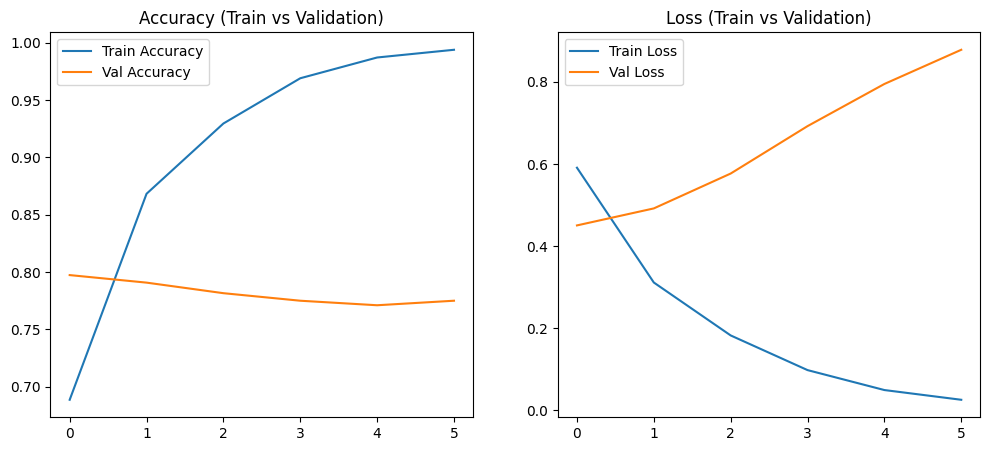

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('../models/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]
model_baseline = Sequential([
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') 
])


model_baseline.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history_baseline = model_baseline.fit(
    X_train_tfidf_clean,
    y_train_clean,
    epochs=30,
    validation_split=0.15,
    callbacks=callbacks_baseline,
    verbose=1
)

model_baseline.summary()

acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title('Accuracy (Train vs Validation)')
plt.legend()

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Loss (Train vs Validation)')
plt.legend()

**=> On observe un fort surapprentissage. La courbe Train Loss tend vers 0 (99% d'accuracy) alors que la courbe Val Loss est à la hausse**
**ce qui est un signe que le modèle mémorise au lieu de généraliser.**

In [55]:
# Analyse de l'overfitting
train_loss_final = history_baseline.history['loss'][-1]
val_loss_final = history_baseline.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("Overfitting modéré")
else:
    print("=> Overfitting significatif")

Train Loss Final: 0.0253
Val Loss Final: 0.8784
Overfitting Gap: 0.8531
=> Overfitting significatif


**=> l'overfitting est "significatif" avec un overfitting gap à 0.82. Pour améliorer le modèle, il faudrait mettre en oeuvre une** 
**régulation avec "kernel_regularizer='l2'" sur les couche dense, augmenter le dropout et diminuer le nombre de neurones par couche**

## Amélioration de l'overfitting

Epoch 1/20
114/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5255 - loss: 1.0662
Epoch 1: val_accuracy improved from None to 0.66447, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5762 - loss: 0.8789 - val_accuracy: 0.6645 - val_loss: 0.7561
Epoch 2/20
106/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6089 - loss: 0.7431
Epoch 2: val_accuracy did not improve from 0.66447
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6212 - loss: 0.7285 - val_accuracy: 0.6566 - val_loss: 0.7125
Epoch 3/20
112/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6291 - loss: 0.7078
Epoch 3: val_accuracy improved from 0.66447 to 0.71053, saving model to ../models/best_model.keras

Epoch 3: finished saving model to ../models/best_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6514 - loss: 0.7036 - val_accuracy: 0.7105 - val_loss: 0.7016
Epoch 4/20
114/135 ━━

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 32)             │        96,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,733 (1.11 MB)

 Trainable params: 96,577 (377.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 193,156 (754.52 KB)

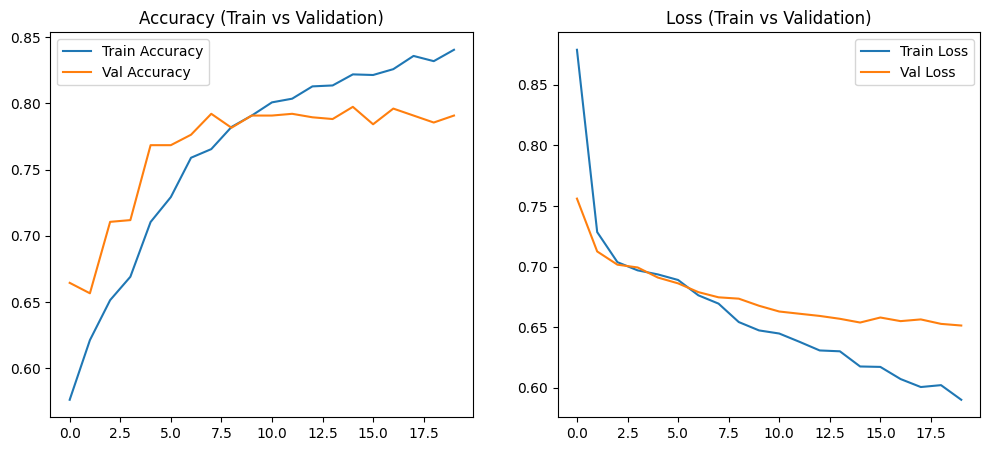

In [56]:
callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('../models/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

model_baseline_ameliore = Sequential([
    Dense(32, activation='relu',kernel_regularizer='l2'),
    Dropout(0.5),
    Dense(16, activation='relu',kernel_regularizer='l2'),
    Dropout(0.4),
    Dense(1, activation='sigmoid') 
])


model_baseline_ameliore.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)



history_baseline_ameliore = model_baseline_ameliore.fit(
    X_train_tfidf_clean,
    y_train_clean,
    epochs=20,
    validation_split=0.15,
    callbacks=callbacks_baseline,
    verbose=1
)

model_baseline_ameliore.summary()

acc = history_baseline_ameliore.history['accuracy']
val_acc = history_baseline_ameliore.history['val_accuracy']
loss = history_baseline_ameliore.history['loss']
val_loss = history_baseline_ameliore.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.title('Accuracy (Train vs Validation)')
plt.legend()

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Loss (Train vs Validation)')
plt.legend()

In [57]:
# Analyse de l'overfitting
train_loss_final = history_baseline_ameliore.history['loss'][-1]
val_loss_final = history_baseline_ameliore.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("=> Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("=> Overfitting modéré")
else:
    print("=> Overfitting significatif")



Train Loss Final: 0.5900
Val Loss Final: 0.6513
Overfitting Gap: 0.0613
=> Overfitting modéré


**=> on observe une nette amelioration avec un overfitting gap qui passe de 0.82 à 0.02**

## 4.2 Modèle avec embeddings appris — architecture séquentielle


Construisez un second modèle intégrant la couche TextVectorization et une couche Embedding :

Architecture :

TextVectorization (vocab_size=5000, sequence_length=30)
Embedding(input_dim=5000, output_dim=64, mask_zero=True)
Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
Dense(64, activation='relu')
Dropout(0.3)
Dense(1, activation='sigmoid')
Même configuration de compilation et de callbacks que le modèle 4.1
Entraînez sur 30 epochs
Tracez les courbes d'apprentissage

Epoch 1/15

Epoch 1: val_loss improved from None to 0.46038, saving model to ../models/best_model_bilstm.keras

Epoch 1: finished saving model to ../models/best_model_bilstm.keras
135/135 - 13s - 97ms/step - accuracy: 0.7044 - loss: 0.5595 - val_accuracy: 0.7974 - val_loss: 0.4604
Epoch 2/15

Epoch 2: val_loss did not improve from 0.46038
135/135 - 5s - 40ms/step - accuracy: 0.8883 - loss: 0.2782 - val_accuracy: 0.8000 - val_loss: 0.4665
Epoch 3/15

Epoch 3: val_loss did not improve from 0.46038
135/135 - 5s - 41ms/step - accuracy: 0.9422 - loss: 0.1567 - val_accuracy: 0.7961 - val_loss: 0.6272
Epoch 4/15

Epoch 4: val_loss did not improve from 0.46038
135/135 - 5s - 40ms/step - accuracy: 0.9684 - loss: 0.1016 - val_accuracy: 0.7855 - val_loss: 0.7788
Epoch 5/15

Epoch 5: val_loss did not improve from 0.46038
135/135 - 5s - 41ms/step - accuracy: 0.9772 - loss: 0.0667 - val_accuracy: 0.7789 - val_loss: 1.0250
Epoch 6/15

Epoch 6: val_loss did not improve from 0.46038
135/135 - 5s - 37ms

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_10           │ (None, 30)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,183,109 (4.51 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 788,740 (3.01 MB)

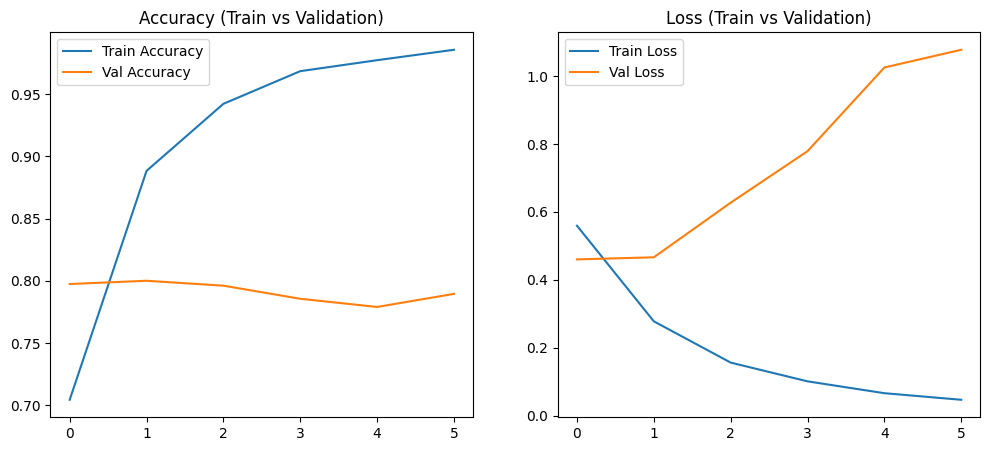

In [58]:
model_bilstm = keras.Sequential([
    # keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer_raw,
    layers.Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


callbacks_bilstm = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_bilstm.keras", monitor="val_loss", save_best_only=True, verbose=1)
]

X_train_raw_array = X_train_raw_emb.fillna("").astype(str).to_numpy()
y_train_raw_array = y_train_raw_emb.to_numpy(dtype="int32")

history_bilstm = model_bilstm.fit(
    X_train_raw_array,
    y_train_raw_array,
    epochs=15,
    validation_split=0.15,
    callbacks=callbacks_bilstm,
    verbose=2
)

model_bilstm.summary()

acc_bilstm = history_bilstm.history['accuracy']
val_acc_bilstm = history_bilstm.history['val_accuracy']
loss_bilstm = history_bilstm.history['loss']
val_loss_bilstm = history_bilstm.history['val_loss']
epochs_range_bilstm = range(len(acc_bilstm))

plt.figure(figsize=(12, 5))

# Courbe d'Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_bilstm, acc_bilstm, label='Train Accuracy')
plt.plot(epochs_range_bilstm, val_acc_bilstm, label='Val Accuracy')
plt.title('Accuracy (Train vs Validation)')
plt.legend()

# Courbe de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_bilstm, loss_bilstm, label='Train Loss')
plt.plot(epochs_range_bilstm, val_loss_bilstm, label='Val Loss')
plt.title('Loss (Train vs Validation)')
plt.legend()

In [59]:
# Analyse de l'overfitting
train_loss_final = history_bilstm.history['loss'][-1]
val_loss_final = history_bilstm.history['val_loss'][-1]
overfitting_gap = val_loss_final - train_loss_final

print(f"Train Loss Final: {train_loss_final:.4f}")
print(f"Val Loss Final: {val_loss_final:.4f}")
print(f"Overfitting Gap: {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("=> Peu d'overfitting détecté")
elif overfitting_gap < 0.15:
    print("=> Overfitting modéré")
else:
    print("=> Overfitting significatif")

Train Loss Final: 0.0474
Val Loss Final: 1.0771
Overfitting Gap: 1.0297
=> Overfitting significatif


**=> l'overfitting est "significatif" avec un overfitting gap à 0.2. Pour améliorer le modèle, il faudrait mettre en oeuvre une** 
**régulation avec "kernel_regularizer='l2'" sur les couche denses, augmenter le dropout et diminuer le nombre de neurones par couche**

## Amélioration de l'overfitting 

Epoch 1/5
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5633 - loss: 0.9206
Epoch 1: val_loss improved from None to 0.69351, saving model to ../models/best_model_bilstm.keras

Epoch 1: finished saving model to ../models/best_model_bilstm.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6203 - loss: 0.8411 - val_accuracy: 0.7039 - val_loss: 0.6935
Epoch 2/5
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7892 - loss: 0.5765
Epoch 2: val_loss improved from 0.69351 to 0.53887, saving model to ../models/best_model_bilstm.keras

Epoch 2: finished saving model to ../models/best_model_bilstm.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8189 - loss: 0.5028 - val_accuracy: 0.8013 - val_loss: 0.5389
Epoch 3/5
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8717 - loss: 0.3773
Epoch 3: val_loss did not improve from 0.53887
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8850 - loss: 0.3428 - val_accuracy: 0.8000 - val_loss: 0.5640
E

ValueError: x and y must have same first dimension, but have shapes (6,) and (5,)

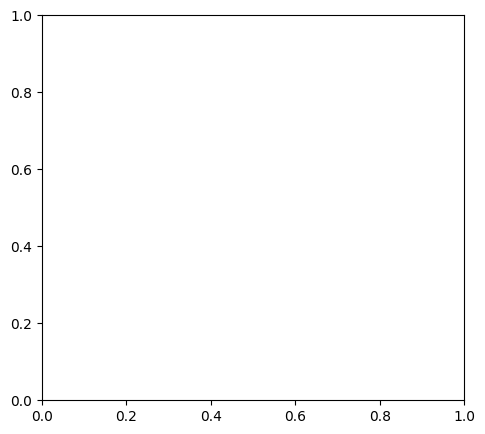

In [60]:
# text_vectorizer_raw_ameliore = tf.keras.layers.TextVectorization(
#     max_tokens=3000,
#     output_sequence_length=30
# )

# vocabulaire_raw_amiliore = [word for word, count in vocabulaire_avant_nettoyage.most_common(2998)]
# text_vectorizer_raw_ameliore.set_vocabulary(vocabulaire_raw_amiliore)

text_vectorizer_raw = tf.keras.layers.TextVectorization(
    max_tokens=3000,
    output_sequence_length=30,
    standardize="lower_and_strip_punctuation" # Nettoyage standard intégré
)

# On "apprend" le vocabulaire sur les données propres (et seulement sur le train !)
text_vectorizer_raw.adapt(X_train_raw_emb.to_numpy())


model_bilstm_ameliore = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer_raw,
    layers.Embedding(input_dim=3000, output_dim=16, mask_zero=True),
    layers.Bidirectional(layers.LSTM(16, dropout=0., recurrent_dropout=0.4)),
    layers.Dense(32, activation="relu",kernel_regularizer='l2'),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_bilstm_ameliore.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_bilstm = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("../models/best_model_bilstm.keras", monitor="val_loss", save_best_only=True, verbose=1)
]

X_train_raw_array = X_train_raw_emb.fillna("").astype(str).to_numpy()
y_train_raw_array = y_train_raw_emb.to_numpy(dtype="int32")

history_bilstm_ameliore = model_bilstm_ameliore.fit(
    X_train_raw_array,
    y_train_raw_array,
    epochs=5,
    validation_split=0.15,
    callbacks=callbacks_bilstm,
    verbose=1
)


acc_bilstm_ameliore = history_bilstm_ameliore.history["accuracy"]
val_acc_bilstm_ameliore = history_bilstm_ameliore.history["val_accuracy"]
loss_bilstm_ameliore = history_bilstm_ameliore.history["loss"]
val_loss_bilstm_ameliore = history_bilstm_ameliore.history["val_loss"]
epochs_range_bilstm = range(len(acc_bilstm))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_bilstm, acc_bilstm_ameliore, label="Train Accuracy")
plt.plot(epochs_range_bilstm, val_acc_bilstm_ameliore, label="Val Accuracy")
plt.title("Accuracy (Train vs Validation) - BiLSTM")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range_bilstm, loss_bilstm, label="Train Loss")
plt.plot(epochs_range_bilstm, val_loss_bilstm, label="Val Loss")
plt.title("Loss (Train vs Validation) - BiLSTM")
plt.legend()

plt.tight_layout()
plt.show()

## 4.3 Comparaison des deux architectures


Remplissez le tableau suivant avec vos résultats mesurés sur l'ensemble de test :

Critère	Modèle Dense (TF-IDF)	Modèle LSTM Bidirectionnel
Accuracy (test)		
Precision — classe FAKE		
Recall — classe FAKE		
F1-score (macro)		
AUC-ROC		
Epochs effectifs (EarlyStopping)		
Nombre de paramètres entraînables		
Temps d'entraînement (approx.)		
Question écrite : Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

In [ ]:
import time
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1) Préparation des jeux de test
# =========================

# Pour le modèle Dense TF-IDF
X_test_dense = X_test_tfidf_clean
y_test_dense = y_test_clean.to_numpy(dtype="int32")

# Pour le modèle BiLSTM
X_test_bilstm = X_test_raw_emb.fillna("").astype(str).to_numpy()
y_test_bilstm = y_test_raw_emb.to_numpy(dtype="int32")


# =========================
# 2) Prédictions
# =========================

# Modèle Dense TF-IDF
y_proba_dense = model_baseline.predict(X_test_dense).ravel()
y_pred_dense = (y_proba_dense >= 0.5).astype(int)

# Modèle BiLSTM
y_proba_bilstm = model_bilstm.predict(X_test_bilstm).ravel()
y_pred_bilstm = (y_proba_bilstm >= 0.5).astype(int)


# =========================
# 3) Métriques
# =========================

def compute_metrics(y_true, y_pred, y_proba, history, model, x_for_timing):
    metrics_dict = {}

    metrics_dict["Accuracy (test)"] = accuracy_score(y_true, y_pred)
    metrics_dict["Precision — classe FAKE"] = precision_score(y_true, y_pred, pos_label=0)
    metrics_dict["Recall — classe FAKE"] = recall_score(y_true, y_pred, pos_label=0)
    metrics_dict["F1-score (macro)"] = f1_score(y_true, y_pred, average="macro")
    metrics_dict["AUC-ROC"] = roc_auc_score(y_true, y_proba)
    metrics_dict["Epochs effectifs"] = len(history.history["loss"])
    metrics_dict["Nombre de paramètres entraînables"] = model.count_params()

    # Temps d'inférence approximatif sur l'ensemble de test
    start = time.perf_counter()
    _ = model.predict(x_for_timing, verbose=0)
    end = time.perf_counter()
    metrics_dict["Temps d'inférence test (s)"] = end - start

    return metrics_dict


metrics_dense = compute_metrics(
    y_true=y_test_dense,
    y_pred=y_pred_dense,
    y_proba=y_proba_dense,
    history=history_baseline,
    model=model_baseline,
    x_for_timing=X_test_dense
)

metrics_bilstm = compute_metrics(
    y_true=y_test_bilstm,
    y_pred=y_pred_bilstm,
    y_proba=y_proba_bilstm,
    history=history_bilstm,
    model=model_bilstm,
    x_for_timing=X_test_bilstm
)


# =========================
# 4) Tableau comparatif
# =========================

comparison_df = pd.DataFrame({
    "Critère": list(metrics_dense.keys()),
    "Modèle Dense (TF-IDF)": list(metrics_dense.values()),
    "Modèle LSTM Bidirectionnel": list(metrics_bilstm.values())
})

comparison_df

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


,Critère,Modèle Dense (TF-IDF),Modèle LSTM Bidirectionnel
0,Accuracy (test),0.803473,0.803473
1,Precision — classe FAKE,0.773504,0.752632
2,Recall — classe FAKE,0.857820,0.903633
3,F1-score (macro),0.802905,0.801510
4,AUC-ROC,0.881676,0.892580
5,Epochs effectifs,6.000000,7.000000
6,Nombre de paramètres entraînables,801281.000000,394369.000000
7,Temps d'inférence test (s),0.209952,0.223134


In [ ]:
models_dict = {
    'Modèle baseline — réseau dense sur TF-IDF': model_baseline,
    'Modèle baseline — réseau dense sur TF-IDF amélioré': model_baseline_ameliore,
    'Modèle avec embeddings appris — architecture séquentielle': model_bilstm,
    'Modèle avec embeddings appris — architecture séquentielle amélioré': model_bilstm_ameliore
}

from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pandas as pd

results = {}


for name, model in models_dict.items():
    print(f"\nÉvaluation {name}...")
    
    if 'embeddings' in name:
        raw_data = X_test_raw_emb.fillna("").values.astype(str)
        data_to_predict = tf.convert_to_tensor(raw_data, dtype=tf.string)
    else:
        data_to_predict = tfidf_clean
    
    # --- PRÉDICTION ---
    y_proba = model.predict(data_to_predict, verbose=0)
    
    # --- TRAITEMENT DU SEUIL (Binaire Sigmoid) ---
    # Si y_proba > 0.5 alors classe 1, sinon classe 0
    y_pred = (y_proba > 0.5).astype(int).flatten()
    
    # --- MÉTRIQUES ---
    acc = accuracy_score(y_test_clean, y_pred)
    f1 = f1_score(y_test_clean, y_pred, average='weighted')
    
    results[name] = {
        'accuracy': acc,
        'f1_score': f1,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f}")

# --- AFFICHAGE DU TABLEAU ---
comparison_df = pd.DataFrame([
    {'Model': name, 'Accuracy': f"{res['accuracy']*100:.2f}%", 'F1 Score': f"{res['f1_score']:.4f}"}
    for name, res in results.items()
])

print("\n--- TABLEAU COMPARATIF FINAL ---")
print(comparison_df.to_string(index=False))


Évaluation Modèle baseline — réseau dense sur TF-IDF...


ValueError: Unrecognized data type: x=TfidfVectorizer(max_df=0.85, max_features=3000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True) (of type <class 'sklearn.feature_extraction.text.TfidfVectorizer'>)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# On récupère les prédictions du meilleur modèle (ex: le BiLSTM amélioré)
best_model_name = 'Modèle avec embeddings appris — architecture séquentielle amélioré'
y_pred_best = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test_clean, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Vrai', 'Fake'], 
            yticklabels=['Vrai', 'Fake'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title(f'Matrice de Confusion\n{best_model_name}')
plt.show()

KeyError: 'Modèle avec embeddings appris — architecture séquentielle amélioré'